<a href="https://colab.research.google.com/github/murtazaarsh7/ml_in_summers2026/blob/main/olympics_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import numpy as np
import pandas as pd

In [72]:
df=pd.read_csv("/content/drive/MyDrive/olympics_analysis/athlete_events.csv")
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [73]:
region_df=pd.read_csv("/content/drive/MyDrive/olympics_analysis/noc_regions.csv")
region_df

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN
...,...,...,...
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN


In [74]:
df.shape


(271116, 15)

In [75]:
df=df[df['Season']=='Summer']

In [76]:
df.shape

(222552, 15)

In [77]:
df.describe()

,ID,Age,Height,Weight,Year
count,222552.000000,213363.000000,170695.000000,168698.00000,222552.000000
mean,67998.925712,25.674053,175.515551,70.68906,1976.317094
std,39139.038228,6.699839,10.914725,14.80394,30.942802
min,1.000000,10.000000,127.000000,25.00000,1896.000000
25%,34000.750000,21.000000,168.000000,60.00000,1956.000000
50%,68302.500000,24.000000,175.000000,70.00000,1984.000000
75%,101881.000000,28.000000,183.000000,79.00000,2000.000000
max,135568.000000,97.000000,226.000000,214.00000,2016.000000


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222552 entries, 0 to 271110
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      222552 non-null  int64  
 1   Name    222552 non-null  object 
 2   Sex     222552 non-null  object 
 3   Age     213363 non-null  float64
 4   Height  170695 non-null  float64
 5   Weight  168698 non-null  float64
 6   Team    222552 non-null  object 
 7   NOC     222552 non-null  object 
 8   Games   222552 non-null  object 
 9   Year    222552 non-null  int64  
 10  Season  222552 non-null  object 
 11  City    222552 non-null  object 
 12  Sport   222552 non-null  object 
 13  Event   222552 non-null  object 
 14  Medal   34088 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 27.2+ MB


In [79]:
df.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,9189
Height,51857
Weight,53854
Team,0
NOC,0
Games,0
Year,0


In [80]:
df=df.merge(region_df,on='NOC',how='left')

In [81]:
df.sample()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
168427,102738,Antonio Rossi,M,39.0,186.0,84.0,Italy,ITA,2008 Summer,2008,Summer,Beijing,Canoeing,"Canoeing Men's Kayak Fours, 1,000 metres",NaN,Italy,NaN


In [82]:
len(df['region'].unique())

206

In [83]:
df.isnull().sum(
)

,0
ID,0
Name,0
Sex,0
Age,9189
Height,51857
Weight,53854
Team,0
NOC,0
Games,0
Year,0


In [84]:
df.duplicated().sum()

np.int64(1385)

In [85]:
df.drop_duplicates(inplace=True)

In [86]:
df['Medal'].value_counts()

,count
Medal,
Gold,11456
Bronze,11409
Silver,11212


In [87]:
pd.get_dummies(df['Medal'],dtype=int)

,Bronze,Gold,Silver
0,0,0,0
1,0,0,0
2,0,0,0
3,0,1,0
4,0,0,0
...,...,...,...
222547,0,0,0
222548,0,0,0
222549,0,0,0
222550,0,0,0


In [88]:
df = pd.concat([df, pd.get_dummies(df['Medal'], dtype=int)], axis=1)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0


In [89]:
df.groupby('NOC').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False).reset_index()
#this contains individual tally as well

,NOC,Gold,Silver,Bronze
0,USA,2472,1333,1197
1,URS,832,635,596
2,GBR,635,729,620
3,GER,592,538,649
4,ITA,518,474,454
...,...,...,...,...
225,WIF,0,0,5
226,YEM,0,0,0
227,YAR,0,0,0
228,YMD,0,0,0


In [90]:
medal_tally=df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])
medal_tally

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222528,135553,Galina Ivanovna Zybina (-Fyodorova),F,25.0,168.0,80.0,Soviet Union,URS,1956 Summer,1956,Summer,Melbourne,Athletics,Athletics Women's Shot Put,Silver,Russia,NaN,0,0,1
222530,135553,Galina Ivanovna Zybina (-Fyodorova),F,33.0,168.0,80.0,Soviet Union,URS,1964 Summer,1964,Summer,Tokyo,Athletics,Athletics Women's Shot Put,Bronze,Russia,NaN,1,0,0
222536,135556,Bogusaw Stanisaw Zychowicz,M,19.0,189.0,80.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 100 metres Butterfly,NaN,Poland,NaN,0,0,0
222537,135556,Bogusaw Stanisaw Zychowicz,M,19.0,189.0,80.0,Poland,POL,1980 Summer,1980,Summer,Moskva,Swimming,Swimming Men's 200 metres Butterfly,NaN,Poland,NaN,0,0,0


In [91]:
medal_tally=medal_tally.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False).reset_index()



In [92]:
medal_tally.sample()

,region,Gold,Silver,Bronze
197,Tonga,0,1,0


In [93]:
medal_tally[medal_tally['region']=="India"]

,region,Gold,Silver,Bronze
47,India,9,7,12


In [94]:
medal_tally['total']=medal_tally['Gold']+medal_tally['Bronze']+medal_tally['Silver']

In [95]:
medal_tally




,region,Gold,Silver,Bronze,total
0,USA,1035,802,708,2545
1,Russia,592,498,487,1577
2,Germany,444,457,491,1392
3,UK,278,317,300,895
4,France,234,256,287,777
...,...,...,...,...,...
200,Vanuatu,0,0,0,0
201,"Virgin Islands, British",0,0,0,0
202,"Virgin Islands, US",0,1,0,1
203,Yemen,0,0,0,0


In [96]:
years=df['Year'].unique().tolist()

In [97]:
years.sort()

In [98]:
years.insert(0,'Overall')
years

['Overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [99]:
country=np.unique(df['region'].dropna().values).tolist()

In [100]:
country.sort()

In [101]:
country


['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Guinea',
 'Guin

In [102]:
def fethch_medal_tally(years,country,df):
  medal_df=df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])
  flag=0
  if years=='Overall' and country=='Overall':
    temp_df= medal_df
  elif years=='Overall' and country!='Overall':
    flag=1
    temp_df= medal_df[medal_df['region']==country]
  elif years!='Overall' and country=='Overall':
    temp_df= medal_df[medal_df['Year']==years]
  elif years!='Overall' and country!='Overall':
    temp_df=medal_df[(medal_df['Year']==years) & (medal_df['region']==country)]
  if flag:
    x=temp_df.groupby('Year').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Year').reset_index()
  else:
    x=temp_df.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False).reset_index()

  x['total']=x['Gold']+x['Bronze']+x['Silver']
  return x


In [103]:
fethch_medal_tally(2016,'India',df)

,region,Gold,Silver,Bronze,total
0,India,0,1,1,2


In [104]:
#overall analysis
#1 no. of editions
#@ no. of cities
#3 no. of events
#4 no. of athletes
#5 no. of particpating nations


In [105]:
#1
df.sample()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
182965,111885,Richard Charles Slaney,M,28.0,201.0,120.0,Great Britain,GBR,1984 Summer,1984,Summer,Los Angeles,Athletics,Athletics Men's Discus Throw,NaN,UK,NaN,0,0,0


In [106]:
len(df['Year'].unique().tolist())

29

In [107]:
#2
cities=df['City'].unique().tolist()
cities=pd.DataFrame(cities)

In [108]:
#3
df['Event'].unique().tolist()

["Basketball Men's Basketball",
 "Judo Men's Extra-Lightweight",
 "Football Men's Football",
 "Tug-Of-War Men's Tug-Of-War",
 "Athletics Women's 100 metres",
 "Athletics Women's 4 x 100 metres Relay",
 "Swimming Men's 400 metres Freestyle",
 "Badminton Men's Singles",
 "Sailing Women's Windsurfer",
 "Swimming Men's 200 metres Breaststroke",
 "Swimming Men's 400 metres Breaststroke",
 "Gymnastics Men's Individual All-Around",
 "Gymnastics Men's Team All-Around",
 "Gymnastics Men's Floor Exercise",
 "Gymnastics Men's Horse Vault",
 "Gymnastics Men's Parallel Bars",
 "Gymnastics Men's Horizontal Bar",
 "Gymnastics Men's Rings",
 "Gymnastics Men's Pommelled Horse",
 "Athletics Men's Shot Put",
 'Art Competitions Mixed Sculpturing, Unknown Event',
 "Handball Women's Handball",
 "Weightlifting Women's Super-Heavyweight",
 "Wrestling Men's Light-Heavyweight, Greco-Roman",
 "Gymnastics Men's Team All-Around, Free System",
 "Water Polo Men's Water Polo",
 'Sailing Mixed Three Person Keelboat',


In [109]:
#VISUALS

In [110]:
#1 NATIONS WITH TIME
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
nations=df.drop_duplicates(['Year','region'])['Year'].value_counts().reset_index().sort_values(by='Year')
nations


,Year,count
28,1896,12
22,1900,31
27,1904,14
26,1906,20
25,1908,22
23,1912,29
24,1920,29
21,1924,45
20,1928,46
19,1932,47


In [112]:
nations.rename(columns={'Year':'Edition','count':'No. of Countries'},inplace=True)

In [113]:
import plotly.express as px

In [114]:
fig=px.line(nations,x='Edition',y='No. of Countries')
fig.show()

In [115]:
events=df.drop_duplicates(['Year','Event'])['Year'].value_counts().reset_index().sort_values(by='Year')
events


,Year,count
28,1896,43
26,1900,90
25,1904,95
27,1906,74
23,1908,109
24,1912,107
14,1920,158
20,1924,131
22,1928,122
21,1932,131


In [116]:
x=df.drop_duplicates(['Year','Sport','Event'])

<Axes: xlabel='Year', ylabel='Sport'>

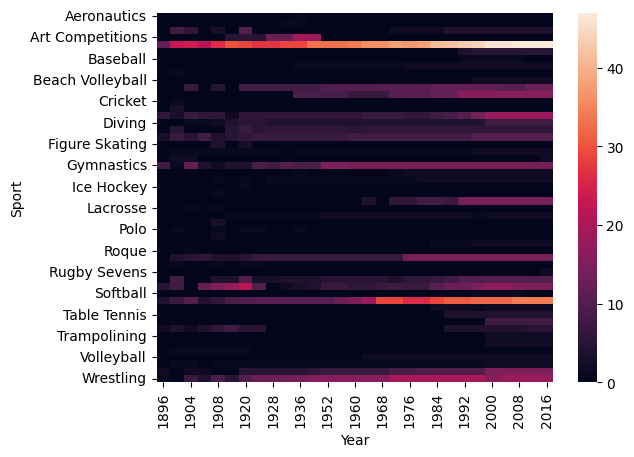

In [117]:
import seaborn as sns
sns.heatmap(x.pivot_table(index='Sport',columns='Year',values='Event',aggfunc='count').fillna(0).astype('int'))

In [118]:
df.sample()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
91346,55977,Karen Julia Josephson,F,24.0,162.0,55.0,United States,USA,1988 Summer,1988,Summer,Seoul,Synchronized Swimming,Synchronized Swimming Women's Duet,Silver,USA,NaN,0,0,1


In [119]:
def most_succesful(df,sport):
  x=df.dropna(subset=['Medal'])
  if sport!='Overall':
    x=x[x['Sport']==sport]
  temp_df=x['Name'].value_counts().reset_index().head(15).merge(df,left_on='Name',right_on='Name',how='left')[['Name','count','region','Sport']].drop_duplicates('Name')
  temp_df.rename(columns={'count':'Medals'},inplace=True)
  return temp_df

In [120]:
most_succesful(df,'Tennis')

,Name,Medals,region,Sport
0,"Maxime Omer Mathieu ""Max"" Omer-Dcugis",6,France,Tennis
7,Venus Ebony Starr Williams,5,USA,Tennis
18,"Kathleen ""Kitty"" McKane (-Godfree)",5,UK,Tennis
24,Serena Jamika Williams,4,USA,Tennis
31,"Arnzazu Isabel Mara ""Arantxa"" Snchez Vicario",4,Spain,Tennis
39,Charles Percy Dixon,4,UK,Tennis
44,Carl Gunnar Emanuel Setterwall,4,Sweden,Tennis
51,"Reginald Frank ""Reggie"" Doherty",4,UK,Tennis
55,Marie Claude Maurice Germot,3,France,Tennis
60,"Stefanie Maria ""Steffi"" Graf",3,Germany,Tennis


In [121]:
def counrty_analyze(df,country):
  x=df.dropna(subset=['Medal'])
  if country!='Overall':
    x=x[x['region']==country]
  temp_df=x['region'].value_counts().reset_index().head(15).merge(df,left_on='region',right_on='region',how='left')[['region','name','count','region','Sport']].drop_duplicates('Name')
  temp_df.rename(columns={'count':'Medals'},inplace=True)
  return temp_df

# **country wise **
1 country wise medal tally
2 heatmp
3 athletes


In [122]:
temp_df=df.dropna(subset=['Medal'])
temp_df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'],inplace=True)

In [123]:
def country_wise(df,country):
  temp_df=df.dropna(subset=['Medal'])
  temp_df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'],inplace=True)
  new_df=temp_df[temp_df['region']==country]
  return new_df.groupby("Year").count()['Medal'].reset_index()


In [124]:
cnt=country_wise(df,'India')

In [125]:
fig=px.line(cnt,x='Year',y='Medal')
fig.show()

In [126]:
def most_succesful(df,country):
  x=df.dropna(subset=['Medal'])
  x=x[x['region']==country]
  temp_df=x['Name'].value_counts().reset_index().head(15).merge(df,left_on='Name',right_on='Name',how='left')[['Name','count','region','Sport']].drop_duplicates('Name')
  temp_df.rename(columns={'count':'Medals'},inplace=True)
  return temp_df

In [127]:
most_succesful(df,'India')

,Name,Medals,region,Sport
0,Leslie Walter Claudius,4,India,Hockey
4,Udham Singh Kular,4,India,Hockey
8,"Victor John ""V. J."" Peter",3,India,Hockey
11,Dhyan Chand Bais,3,India,Hockey
14,Richard James Allen,3,India,Hockey
17,Shankar Pillay Laxman,3,India,Hockey
20,Balbir Singh,3,India,Hockey
23,Harbinder Singh Chimni,3,India,Hockey
26,Prithipal Singh,3,India,Hockey
29,Ranganathan Francis,3,India,Hockey


In [128]:
import plotly.figure_factory as ff

In [129]:
new_df=df.drop_duplicates(subset=['Name','region'])



In [130]:
x1=new_df['Age'].dropna()
x2=new_df[new_df['Medal']=='Gold']['Age'].dropna()
x3=new_df[new_df['Medal']=='Silver']['Age'].dropna()
x4=new_df[new_df['Medal']=='Bronze']['Age'].dropna()

In [131]:
fig=ff.create_distplot([x1,x2,x3,x4],['Overall Age','Gold Medalist','Silver Medalist','Bronze Medalist'],show_hist=False,show_rug=False)
fig.show()

In [132]:
df['Sport'].unique()

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Equestrianism',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Modern Pentathlon', 'Golf', 'Softball', 'Archery',
       'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
       'Rhythmic Gymnastics', 'Rugby Sevens', 'Trampolining',
       'Beach Volleyball', 'Triathlon', 'Rugby', 'Lacrosse', 'Polo',
       'Cricket', 'Ice Hockey', 'Racquets', 'Motorboating', 'Croquet',
       'Figure Skating', 'Jeu De Paume', 'Roque', 'Basque Pelota',
       'Alpinism', 'Aeronautics'], dtype=object)

In [133]:
famous_sport=['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Golf', 'Softball', 'Archery',
       'Volleyball',  'Table Tennis', 'Baseball',
       'Beach Volleyball', 'Rugby', 'Polo','Ice Hockey']



In [134]:
x=[]
name=[]

for sport in famous_sport:
  temp_df=new_df[new_df['Sport']==sport]
  x.append(temp_df[temp_df['Medal']=='Silver']['Age'].dropna())
  name.append(sport)

fig=ff.create_distplot(x,name,show_hist=False,show_rug=False)
fig.show()

In [135]:
new_df['Medal'].fillna('No Medal',inplace =True)

/tmp/ipykernel_1372/15723709.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





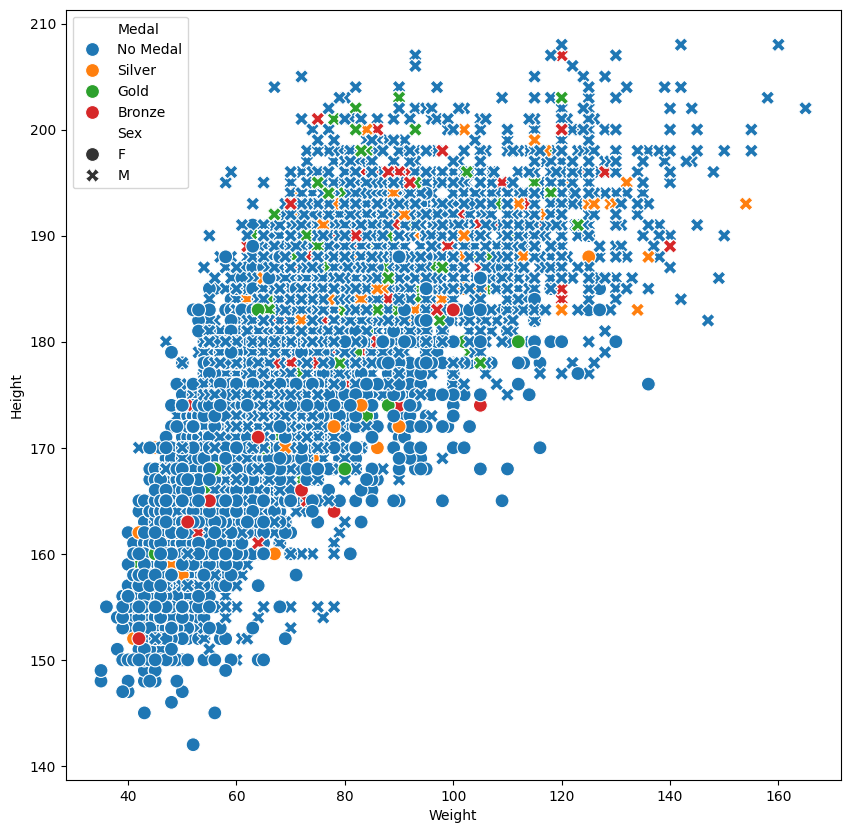

In [136]:
plt.figure(figsize=(10,10))
temp=new_df[new_df['Sport']=='Athletics']
sns.scatterplot(x='Weight',y='Height',hue='Medal',style='Sex',data=temp,s=100)
plt.show()

In [137]:
men=new_df[new_df['Sex']=='M'].groupby('Year').count()['Name'].reset_index()
women=new_df[new_df['Sex']=='F'].groupby('Year').count()['Name'].reset_index()


In [138]:
final=men.merge(women,on='Year',how='left')
final = final.rename(columns={"Name_x":'Male','Name_y':'Female'})

In [139]:
final.fillna(0,inplace=True)

In [140]:
fig=px.line(final,x='Year',y=['Male','Female'])
fig.show()